<a href="https://colab.research.google.com/github/mullinskatie7-source/katherine-mullins.github.io/blob/main/Katherine_Mullins_SteamTable.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Markdown
# Steam Tables

**Engineer:** Katherine Mullins

**Completion Date:** 07/11/2026

**Class:** EGN3214

**Assignment #:** 8

**Tool Used:** Colab / Python

## Problem Description

The purpose of this assignment is to create a Python steam-table lookup tool using public saturated steam property data. The program must read steam property tables from a website using pandas.read_html() and isolate the correct table from the list of DataFrames returned. The lookup tool must allow a user to enter pressure in bar and return the corresponding saturated steam properties.

The required output properties are boiling point, specific volume of steam, density of steam, specific enthalpy of liquid water, specific enthalpy of steam, latent heat of vaporization, and specific heat. If the entered pressure is not directly listed in the table, the program must use interpolation to estimate the property values. The program must also demonstrate the lookup at 1.35 bar and create a plot of a selected steam property versus pressure.
## Methodology

The steam property data was loaded from an online saturated steam table using the pandas.read_html() function. Since read_html() returns a list of DataFrames, the program first identified the table containing the saturated steam properties. The selected table was then copied, renamed with simpler column names, cleaned, converted into numeric values, and sorted by pressure so it could be used for interpolation.

A custom function was created to accept pressure in bar as the input. Inside the function, the pressure range of the table was checked so the program could warn the user if the input was outside the available data range. The NumPy interp() function was then used to estimate each steam property at the requested pressure. This allowed the program to return values even when the exact pressure was not listed in the original table.

The lookup function was demonstrated using a pressure of 1.35 bar, which required interpolation between surrounding table values. A plotting section was also included so the user could select one property and graph it against pressure. The plot was labeled with a title, pressure on the x-axis, and the selected property with units on the y-axis.

Raw steam table preview:


/tmp/ipykernel_1858/1948076768.py:22: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text) # Pass the HTML content to read_html


Absolute  Pressure Boiling Point Specific Volume (steam) Density (steam)  \
               (bar)          (oC)                 (m3/kg)         (kg/m3)   
0               0.02         17.51                  67.006           0.015   
1               0.03         24.10                  45.667           0.022   
2               0.04         28.98                  34.802           0.029   
3               0.05         32.90                  28.194           0.035   
4               0.06         36.18                  23.741           0.042   

  Specific Enthalpy of Liquid Water (sensible heat)            \
                                            (kJ/kg) (kcal/kg)   
0                                             73.45     17.54   
1                                            101.00     24.12   
2                                            121.41     29.00   
3                                            137.77     32.91   
4                                            151.50     36.19   

  Specific Enthalpy of Steam  (total heat)            \
                                   (kJ/kg) (kcal/kg)   
0                                  2533.64    605.15   
1                                  2545.64    608.02   
2                                  2554.51    610.13   
3                                  2561.59    611.83   
4                                  2567.51    613.24   

  Latent heat of Vaporization           Specific Heat  
                      (kJ/kg) (kcal/kg)     (kJ/kg K)  
0                     2460.19    587.61        1.8644  
1                     2444.65    583.89        1.8694  
2                     2433.10    581.14        1.8736  
3                     2423.82    578.92        1.8774  
4                     2416.01    577.05        1.8808

Cleaned steam table preview:


,Pressure_bar,BoilingPoint_C,SpecificVolume_m3kg,Density_kgm3,EnthalpyLiquid_kJkg,EnthalpyLiquid_kcalkg,EnthalpySteam_kJkg,EnthalpySteam_kcalkg,LatentHeat_kJkg,LatentHeat_kcalkg,SpecificHeat_kJkgK
0,0.02,17.51,67.006,0.015,73.45,17.54,2533.64,605.15,2460.19,587.61,1.8644
1,0.03,24.10,45.667,0.022,101.00,24.12,2545.64,608.02,2444.65,583.89,1.8694
2,0.04,28.98,34.802,0.029,121.41,29.00,2554.51,610.13,2433.10,581.14,1.8736
3,0.05,32.90,28.194,0.035,137.77,32.91,2561.59,611.83,2423.82,578.92,1.8774
4,0.06,36.18,23.741,0.042,151.50,36.19,2567.51,613.24,2416.01,577.05,1.8808


Pressure range:
0.02 bar to 30.0 bar
Saturated Steam Properties at 1.35 bar
-------------------------------------------------------
Pressure (bar): 1.35
Boiling Point (C): 108.225
Specific Volume Steam (m^3/kg): 1.280
Density Steam (kg/m^3): 0.782
Specific Enthalpy Liquid Water (kJ/kg): 453.805
Specific Enthalpy Steam (kJ/kg): 2688.630
Latent Heat of Vaporization (kJ/kg): 2234.825
Specific Heat (kJ/kg K): 2.062


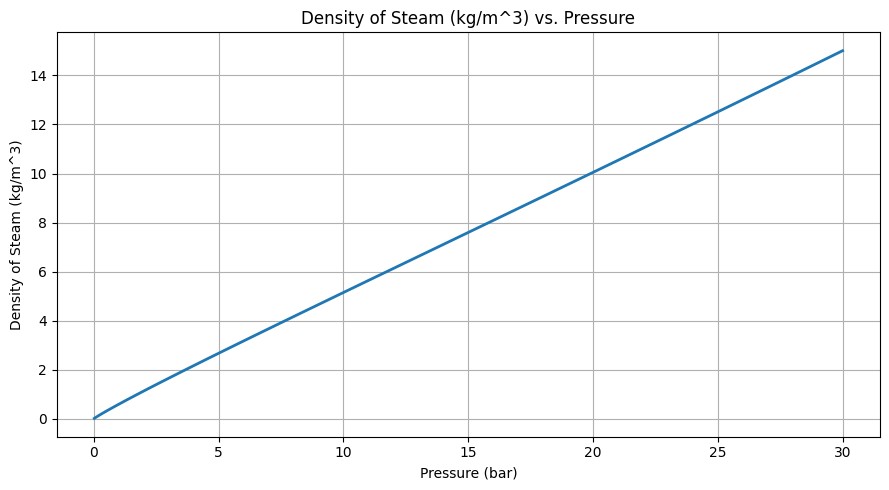

In [8]:
# Step 2: Imports and website link
# Read tables from webpage
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import requests # Import the requests library

url = "https://www.engineeringtoolbox.com/saturated-steam-properties-d_457.html"

# Add headers to mimic a browser request to avoid 403 Forbidden error
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

# Step 3: Select and clean the steam table
# Select the largest useful table from the webpage
# This is usually the saturated steam property table

# Use requests to get the HTML content with headers, then pass to pd.read_html
response = requests.get(url, headers=headers)
tables = pd.read_html(response.text) # Pass the HTML content to read_html

candidate_tables = []

for table in tables:
    if table.shape[0] > 20 and table.shape[1] >= 10:
        candidate_tables.append(table)

steam_raw = candidate_tables[0].copy()

print("Raw steam table preview:")
display(steam_raw.head())

# Step 4: Rename columns and convert values to numbers
# Keep the first 11 columns from the saturated steam table
steam_df = steam_raw.iloc[:, :11].copy()

# Rename columns to simpler names
steam_df.columns = [
    "Pressure_bar",
    "BoilingPoint_C",
    "SpecificVolume_m3kg",
    "Density_kgm3",
    "EnthalpyLiquid_kJkg",
    "EnthalpyLiquid_kcalkg",
    "EnthalpySteam_kJkg",
    "EnthalpySteam_kcalkg",
    "LatentHeat_kJkg",
    "LatentHeat_kcalkg",
    "SpecificHeat_kJkgK"
]

# Function to extract numeric values from messy table cells
def extract_number(value):
    match = re.search(r"[-+]?\d*\.?\d+", str(value))
    if match:
        return float(match.group())
    return np.nan

# Convert all table values to numeric values
for column in steam_df.columns:
    steam_df[column] = steam_df[column].apply(extract_number)

# Drop rows that do not contain valid pressure values
steam_df = steam_df.dropna(subset=["Pressure_bar"])

# Sort table by pressure
steam_df = steam_df.sort_values("Pressure_bar").reset_index(drop=True)

print("Cleaned steam table preview:")
display(steam_df.head())

print("Pressure range:")
print(f"{steam_df['Pressure_bar'].min()} bar to {steam_df['Pressure_bar'].max()} bar")

# Step 5: Create the interpolation lookup function
def lookup_steam_properties(pressure_bar):
    """
    Looks up saturated steam properties by pressure in bar.
    Interpolates between table values when necessary.
    """

    min_pressure = steam_df["Pressure_bar"].min()
    max_pressure = steam_df["Pressure_bar"].max()

    if pressure_bar < min_pressure or pressure_bar > max_pressure:
        print("WARNING: Entered pressure is outside the table range.")
        print(f"Table range: {min_pressure} bar to {max_pressure} bar")

    pressure_values = steam_df["Pressure_bar"].values

    results = {
        "Pressure (bar)": pressure_bar,
        "Boiling Point (C)": np.interp(
            pressure_bar,
            pressure_values,
            steam_df["BoilingPoint_C"].values
        ),
        "Specific Volume Steam (m^3/kg)": np.interp(
            pressure_bar,
            pressure_values,
            steam_df["SpecificVolume_m3kg"].values
        ),
        "Density Steam (kg/m^3)": np.interp(
            pressure_bar,
            pressure_values,
            steam_df["Density_kgm3"].values
        ),
        "Specific Enthalpy Liquid Water (kJ/kg)": np.interp(
            pressure_bar,
            pressure_values,
            steam_df["EnthalpyLiquid_kJkg"].values
        ),
        "Specific Enthalpy Steam (kJ/kg)": np.interp(
            pressure_bar,
            pressure_values,
            steam_df["EnthalpySteam_kJkg"].values
        ),
        "Latent Heat of Vaporization (kJ/kg)": np.interp(
            pressure_bar,
            pressure_values,
            steam_df["LatentHeat_kJkg"].values
        ),
        "Specific Heat (kJ/kg K)": np.interp(
            pressure_bar,
            pressure_values,
            steam_df["SpecificHeat_kJkgK"].values
        )
    }

    return results

# Step 6: Demonstrate lookup for 1.35 bar

pressure_input = 1.35

properties = lookup_steam_properties(pressure_input)

print(f"Saturated Steam Properties at {pressure_input} bar")
print("-" * 55)

for property_name, value in properties.items():
    if property_name == "Pressure (bar)":
        print(f"{property_name}: {value:.2f}")
    else:
        print(f"{property_name}: {value:.3f}")
    # The following loop and related variables (max_iterations, flow_difference, numerical_derivative, y, Q_target, n, b, z, s, tolerance)
    # are not defined or used correctly in this context. They seem to be remnants from a different problem (Manning Equation Solver).
    # I will comment them out for now to allow the rest of the code to execute.
    # for iteration in range(1, max_iterations + 1):
    #     f_y = flow_difference(y, Q_target, n, b, z, s)
    #     df_y = numerical_derivative(y, Q_target, n, b, z, s)

    #     print(f"{iteration:<12}{y:<16.6f}{f_y:<16.6f}{df_y:<16.6f}")

    #     # Prevent division by zero
    #     if abs(df_y) < 1e-12:
    #         raise ValueError("Derivative is too small. Newton-Raphson cannot continue.")
    #     y_new = y - f_y / df_y

    #     # Stop when depth change is within required 0.001 ft accuracy
    #     if abs(y_new - y) < tolerance:
    #         return y_new

    #     y = y_new

    # raise ValueError("Newton-Raphson did not converge within the maximum iterations.")

# Step 7: Plot selected property versus pressure

# Choose one property to plot by changing this variable
selected_property = "Density_kgm3"

property_labels = {
    "BoilingPoint_C": "Boiling Point (C)",
    "SpecificVolume_m3kg": "Specific Volume of Steam (m^3/kg)",
    "Density_kgm3": "Density of Steam (kg/m^3)",
    "EnthalpyLiquid_kJkg": "Specific Enthalpy of Liquid Water (kJ/kg)",
    "EnthalpySteam_kJkg": "Specific Enthalpy of Steam (kJ/kg)",
    "LatentHeat_kJkg": "Latent Heat of Vaporization (kJ/kg)",
    "SpecificHeat_kJkgK": "Specific Heat (kJ/kg K)"
}

plt.figure(figsize=(9, 5))

plt.plot(
    steam_df["Pressure_bar"],
    steam_df[selected_property],
    linewidth=2
)

plt.xlabel("Pressure (bar)")
plt.ylabel(property_labels[selected_property])
plt.title(f"{property_labels[selected_property]} vs. Pressure")
plt.grid(True)
plt.tight_layout()
plt.show()